## **01. Importación de Métodos MADM**

In [1]:
!pip install pymcdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 4.1 MB/s eta 0:00:00


### **01.1 Definición Formal de Manejo de Pesos en el Software**

$\begin{equation}
\texttt{equal\_weights}, \quad
\texttt{user\_defined\_weights}, \quad
\texttt{entropy}, \quad
\texttt{critic}
\end{equation}$

Sea la matriz de decisión normalizada del subconjunto no dominado:

\begin{equation}
\mathbf{R}^{P} =
\left[
r^{P}_{ij}
\right]_{p \times m}
\end{equation}

donde \(p\) es el número de alternativas no dominadas, \(m\) es el número de criterios, y $(r^{P}_{ij})$ representa el valor normalizado de la alternativa \(i\) en el criterio \(j\).

El vector de pesos se define como:

\begin{equation}
\mathbf{w} =
\left[
w_1, w_2, \dots, w_m
\right]
\end{equation}

sujeto a:

\begin{equation}
w_j \geq 0,
\qquad
\sum_{j=1}^{m} w_j = 1
\end{equation}

#### **01.1.1 Todos los pesos Iguales: "Equal Weights"**

\begin{equation}
w_j =
\frac{1}{m},
\qquad
j = 1,2,\dots,m
\end{equation}

Por tanto:
\begin{equation}
\mathbf{w} =
\left[
\frac{1}{m},
\frac{1}{m},
\dots,
\frac{1}{m}
\right]
\end{equation}

#### **01.1.2 Pesos Definidos por Usuario: "User Defined Weights"**

En este caso, el usuario proporciona directamente un vector de pesos preliminares

\begin{equation}
\mathbf{q} =
\left[
q_1, q_2, \dots, q_m
\right],
\qquad
q_j \geq 0
\end{equation}

Para garantizar que los pesos sumen uno, se normalizan como:

\begin{equation}
w_j =
\frac{q_j}
{\sum\limits_{k=1}^{m} q_k},
\qquad
j = 1,2,\dots,m
\end{equation}

con la condición:

\begin{equation}
\sum_{k=1}^{m} q_k > 0
\end{equation}

#### **01.1.3 "Entropy Weights"**

El método de entropía asigna mayor peso a los criterios que presentan mayor capacidad de discriminación entre alternativas.

Primero se calcula la proporción de cada alternativa respecto al total del criterio:

\begin{equation}
p_{ij} =
\frac{r^{P}_{ij}}
{\sum\limits_{i=1}^{p} r^{P}_{ij}},
\qquad
i = 1,2,\dots,p,
\quad
j = 1,2,\dots,m
\end{equation}

con la condición:

\begin{equation}
\sum_{i=1}^{p} r^{P}_{ij} > 0
\end{equation}

La entropía del criterio j se define como:

\begin{equation}
e_j =
-
\frac{1}{\ln(p)}
\sum_{i=1}^{p}
p_{ij}\ln(p_{ij})
\end{equation}

donde se adopta la convención:

\begin{equation}
p_{ij}\ln(p_{ij}) = 0
\quad
\text{si}
\quad
p_{ij}=0
\end{equation}

Luego se calcula el grado de diversificación o información útil del criterio:

\begin{equation}
g_j =
1 - e_j
\end{equation}

Finalmente, el peso por entropía se obtiene como:

\begin{equation}
w_j =
\frac{g_j}
{\sum\limits_{k=1}^{m} g_k},
\qquad
j = 1,2,\dots,m
\end{equation}

con la condición:

\begin{equation}
\sum_{k=1}^{m} g_k > 0
\end{equation}

#### **01.1.4 "CRITIC Weights"**

El método CRITIC pondera los criterios considerando dos elementos:

\begin{equation}
\text{contraste del criterio}
\quad
\text{y}
\quad
\text{conflicto con los demás criterios}
\end{equation}

El contraste del criterio j se mide mediante su desviación estándar:

\begin{equation}
\sigma_j =
\sqrt{
\frac{1}{p}
\sum_{i=1}^{p}
\left(
r^{P}_{ij} - \bar{r}^{P}_{j}
\right)^2
}
\end{equation}

donde:

\begin{equation}
\bar{r}^{P}_{j}
=
\frac{1}{p}
\sum_{i=1}^{p}
r^{P}_{ij}
\end{equation}

Luego se calcula el coeficiente de correlación entre los criterios j y k:

\begin{equation}
\rho_{jk} =
\frac{
\sum\limits_{i=1}^{p}
\left(
r^{P}_{ij} - \bar{r}^{P}_{j}
\right)
\left(
r^{P}_{ik} - \bar{r}^{P}_{k}
\right)
}
{
\sqrt{
\sum\limits_{i=1}^{p}
\left(
r^{P}_{ij} - \bar{r}^{P}_{j}
\right)^2
}
\sqrt{
\sum\limits_{i=1}^{p}
\left(
r^{P}_{ik} - \bar{r}^{P}_{k}
\right)^2
}
}
\end{equation}

El nivel de conflicto del criterio j respecto a los demás criterios se define como:

\begin{equation}
C_j =
\sum_{k=1}^{m}
\left(
1 - \rho_{jk}
\right)
\end{equation}

La cantidad de información aportada por el criterio j es:

\begin{equation}
I_j =
\sigma_j C_j
=
\sigma_j
\sum_{k=1}^{m}
\left(
1 - \rho_{jk}
\right)
\end{equation}

Finalmente, el peso CRITIC se obtiene como:

\begin{equation}
w_j =
\frac{I_j}
{\sum\limits_{k=1}^{m} I_k},
\qquad
j = 1,2,\dots,m
\end{equation}

con la condición:

\begin{equation}
\sum_{k=1}^{m} I_k > 0
\end{equation}

### **01.2 Resumen General**

\begin{align}
\text{Equal Weights:}
\qquad
w_j &=
\frac{1}{m}
\\[10pt]
\text{User Defined Weights:}
\qquad
w_j &=
\frac{q_j}{\sum\limits_{k=1}^{m} q_k}
\\[10pt]
\text{Entropy Weights:}
\qquad
w_j &=
\frac{1-e_j}
{\sum\limits_{k=1}^{m} (1-e_k)}
\\[10pt]
\text{CRITIC Weights:}
\qquad
w_j &=
\frac{
\sigma_j
\sum\limits_{k=1}^{m}
(1-\rho_{jk})
}
{
\sum\limits_{\ell=1}^{m}
\left[
\sigma_\ell
\sum\limits_{k=1}^{m}
(1-\rho_{\ell k})
\right]
}
\end{align}

## **02. Definición de Clases para Cálculo MADM**

### **02.1 Clase de Cálculo de Pesos**

In [2]:
from __future__ import annotations

from dataclasses import dataclass
from enum import Enum
from typing import Any, Sequence

import numpy as np
import numpy.typing as npt

from pymcdm.methods import (
    TOPSIS,
    VIKOR,
    COPRAS,
    ARAS,
    CODAS,
    EDAS,
    MABAC,
    MARCOS,
    MOORA,
    WASPAS,
    WSM,
    WPM,
)


class Direction(str, Enum):
    MIN = "min"
    MAX = "max"


class MatrixOrientation(str, Enum):
    """
    Indicates how the decision matrix should be interpreted by MADM methods.

    ORIGINAL_DIRECTIONS:
        The matrix still contains cost and benefit criteria according to
        the provided directions.

    ALL_BENEFIT:
        The matrix was already transformed so that higher is better for
        every criterion.
    """

    ORIGINAL_DIRECTIONS = "original_directions"
    ALL_BENEFIT = "all_benefit"


class WeightMethod(str, Enum):
    EQUAL = "equal_weights"
    USER_DEFINED = "user_defined_weights"
    ENTROPY = "entropy"
    CRITIC = "critic"


class MADMMethod(str, Enum):
    TOPSIS = "topsis"
    VIKOR = "vikor"
    COPRAS = "copras"
    ARAS = "aras"
    CODAS = "codas"
    EDAS = "edas"
    MABAC = "mabac"
    MARCOS = "marcos"
    MOORA = "moora"
    WASPAS = "waspas"
    WSM = "wsm"
    WPM = "wpm"


@dataclass(frozen=True, slots=True)
class WeightResult:
    method: WeightMethod
    weights: npt.NDArray[np.float64]
    dimensions: list[str]

    def to_dict(self) -> dict[str, Any]:
        return {
            "method": self.method.value,
            "weights": self.weights.tolist(),
            "dimensions": self.dimensions,
            "weights_by_dimension": {
                dimension: float(weight)
                for dimension, weight in zip(self.dimensions, self.weights)
            },
        }


@dataclass(frozen=True, slots=True)
class MADMResult:
    method: MADMMethod
    weight_method: WeightMethod
    alternatives: list[str]
    dimensions: list[str]
    weights: npt.NDArray[np.float64]
    scores: npt.NDArray[np.float64]
    ranking_positions: npt.NDArray[np.int64]
    ranked_alternatives: list[str]
    best_alternative: str
    best_index: int
    matrix_orientation: MatrixOrientation

    def to_dict(self) -> dict[str, Any]:
        return {
            "method": self.method.value,
            "weight_method": self.weight_method.value,
            "alternatives": self.alternatives,
            "dimensions": self.dimensions,
            "weights": self.weights.tolist(),
            "weights_by_dimension": {
                dimension: float(weight)
                for dimension, weight in zip(self.dimensions, self.weights)
            },
            "scores": self.scores.tolist(),
            "scores_by_alternative": {
                alternative: float(score)
                for alternative, score in zip(self.alternatives, self.scores)
            },
            "ranking_positions": self.ranking_positions.tolist(),
            "ranking_by_alternative": {
                alternative: int(rank)
                for alternative, rank in zip(self.alternatives, self.ranking_positions)
            },
            "ranked_alternatives": self.ranked_alternatives,
            "best_alternative": self.best_alternative,
            "best_index": self.best_index,
            "matrix_orientation": self.matrix_orientation.value,
        }


class WeightCalculator:
    """
    Computes criterion weights for MADM methods.

    Supported methods:
    - equal_weights
    - user_defined_weights
    - entropy
    - critic

    The matrix should preferably be a normalized decision matrix. For entropy
    and CRITIC, it is recommended to use a matrix where all criteria are already
    benefit-oriented and non-negative.
    """

    def __init__(
        self,
        matrix: Sequence[Sequence[float]] | npt.NDArray[np.float64],
        *,
        dimensions: Sequence[str] | None = None,
        epsilon: float = 1e-12,
    ) -> None:
        self._matrix = np.asarray(matrix, dtype=np.float64)
        self._epsilon = float(epsilon)

        self._validate_matrix()

        self._n_alternatives: int = self._matrix.shape[0]
        self._n_dimensions: int = self._matrix.shape[1]

        self._dimensions = (
            list(dimensions)
            if dimensions is not None
            else [f"C{j + 1}" for j in range(self._n_dimensions)]
        )

        self._validate_dimensions()

    @staticmethod
    def _parse_weight_method(method: str | WeightMethod) -> WeightMethod:
        if isinstance(method, WeightMethod):
            return method

        normalized = str(method).strip().lower()

        aliases = {
            "equal": WeightMethod.EQUAL,
            "equal_weights": WeightMethod.EQUAL,
            "mean": WeightMethod.EQUAL,
            "mean_weights": WeightMethod.EQUAL,
            "user": WeightMethod.USER_DEFINED,
            "user_defined": WeightMethod.USER_DEFINED,
            "user_defined_weights": WeightMethod.USER_DEFINED,
            "entropy": WeightMethod.ENTROPY,
            "entropy_weights": WeightMethod.ENTROPY,
            "critic": WeightMethod.CRITIC,
            "critic_weights": WeightMethod.CRITIC,
        }

        if normalized not in aliases:
            valid = [method.value for method in WeightMethod]
            raise ValueError(
                f"Invalid weight method '{method}'. Valid methods are: {valid}."
            )

        return aliases[normalized]

    def _validate_matrix(self) -> None:
        if self._matrix.ndim != 2:
            raise ValueError("matrix must be a two-dimensional array.")

        if self._matrix.size == 0:
            raise ValueError("matrix cannot be empty.")

        if not np.all(np.isfinite(self._matrix)):
            raise ValueError("matrix contains NaN or infinite values.")

        if self._epsilon <= 0:
            raise ValueError("epsilon must be greater than zero.")

    def _validate_dimensions(self) -> None:
        if len(self._dimensions) != self._n_dimensions:
            raise ValueError(
                "The number of dimensions must match the number of matrix columns. "
                f"Expected {self._n_dimensions}, got {len(self._dimensions)}."
            )

        if len(set(self._dimensions)) != len(self._dimensions):
            raise ValueError("Dimension names must be unique.")

    def compute(
        self,
        method: str | WeightMethod,
        *,
        user_weights: Sequence[float] | npt.NDArray[np.float64] | None = None,
    ) -> WeightResult:
        selected_method = self._parse_weight_method(method)

        if selected_method == WeightMethod.EQUAL:
            weights = self._equal_weights()

        elif selected_method == WeightMethod.USER_DEFINED:
            if user_weights is None:
                raise ValueError(
                    "user_weights must be provided when method='user_defined_weights'."
                )
            weights = self._user_defined_weights(user_weights)

        elif selected_method == WeightMethod.ENTROPY:
            weights = self._entropy_weights()

        elif selected_method == WeightMethod.CRITIC:
            weights = self._critic_weights()

        else:
            raise NotImplementedError(
                f"Weight method '{selected_method.value}' is not implemented."
            )

        return WeightResult(
            method=selected_method,
            weights=weights,
            dimensions=self._dimensions.copy(),
        )

    def compute_as_dict(
        self,
        method: str | WeightMethod,
        *,
        user_weights: Sequence[float] | npt.NDArray[np.float64] | None = None,
    ) -> dict[str, Any]:
        return self.compute(method, user_weights=user_weights).to_dict()

    def compute_all_as_dict(
        self,
        *,
        user_weights: Sequence[float] | npt.NDArray[np.float64] | None = None,
    ) -> dict[str, Any]:
        output: dict[str, Any] = {}

        for method in WeightMethod:
            if method == WeightMethod.USER_DEFINED and user_weights is None:
                continue

            output[method.value] = self.compute(
                method,
                user_weights=user_weights,
            ).to_dict()

        return output

    def _equal_weights(self) -> npt.NDArray[np.float64]:
        return np.full(
            self._n_dimensions,
            1.0 / self._n_dimensions,
            dtype=np.float64,
        )

    def _user_defined_weights(
        self,
        user_weights: Sequence[float] | npt.NDArray[np.float64],
    ) -> npt.NDArray[np.float64]:
        weights = np.asarray(user_weights, dtype=np.float64)

        if weights.ndim != 1:
            raise ValueError("user_weights must be a one-dimensional vector.")

        if len(weights) != self._n_dimensions:
            raise ValueError(
                "The number of user weights must match the number of dimensions. "
                f"Expected {self._n_dimensions}, got {len(weights)}."
            )

        if not np.all(np.isfinite(weights)):
            raise ValueError("user_weights contains NaN or infinite values.")

        if np.any(weights < 0):
            raise ValueError("user_weights cannot contain negative values.")

        weight_sum = np.sum(weights)

        if weight_sum <= self._epsilon:
            raise ValueError("The sum of user_weights must be greater than zero.")

        return weights / weight_sum

    def _entropy_weights(self) -> npt.NDArray[np.float64]:
        """
        Entropy weighting.

        Assumes a non-negative matrix. If a column has all zero values,
        that column receives no information contribution.
        """
        x = self._matrix.copy()

        if np.any(x < -self._epsilon):
            raise ValueError(
                "Entropy weights require a non-negative matrix. "
                "Use a [0,1] normalization such as directional_minmax first."
            )

        x = np.maximum(x, 0.0)
        column_sums = np.sum(x, axis=0)

        p = np.zeros_like(x, dtype=np.float64)

        valid_columns = column_sums > self._epsilon
        p[:, valid_columns] = x[:, valid_columns] / column_sums[valid_columns]

        n = self._n_alternatives

        if n <= 1:
            return self._equal_weights()

        log_n = np.log(n)

        entropy = np.zeros(self._n_dimensions, dtype=np.float64)

        for j in range(self._n_dimensions):
            column = p[:, j]
            positive = column > self._epsilon

            if not np.any(positive):
                entropy[j] = 1.0
            else:
                entropy[j] = -np.sum(column[positive] * np.log(column[positive])) / log_n

        diversification = 1.0 - entropy
        diversification = np.maximum(diversification, 0.0)

        total = np.sum(diversification)

        if total <= self._epsilon:
            return self._equal_weights()

        return diversification / total

    def _critic_weights(self) -> npt.NDArray[np.float64]:
        """
        CRITIC weighting.

        Uses the standard deviation of each criterion and the conflict between
        criteria measured through correlation.
        """
        x = self._matrix.copy()

        stds = np.std(x, axis=0, ddof=0)

        if np.all(stds <= self._epsilon):
            return self._equal_weights()

        correlation = np.corrcoef(x, rowvar=False)
        correlation = np.nan_to_num(correlation, nan=0.0, posinf=0.0, neginf=0.0)

        conflict = np.sum(1.0 - correlation, axis=1)
        information = stds * conflict
        information = np.maximum(information, 0.0)

        total = np.sum(information)

        if total <= self._epsilon:
            return self._equal_weights()

        return information / total

### **02.2 Clase para métodos MADM**

In [3]:
class MADMRanker:
    """
    MADM ranking engine based on pyMCDM.

    The class receives a decision matrix, alternatives, dimensions and
    directions. It can run one or multiple MADM methods using a given
    weight vector or a selected weighting strategy.
    """

    _METHOD_REGISTRY: dict[MADMMethod, type] = {
        MADMMethod.TOPSIS: TOPSIS,
        MADMMethod.VIKOR: VIKOR,
        MADMMethod.COPRAS: COPRAS,
        MADMMethod.ARAS: ARAS,
        MADMMethod.CODAS: CODAS,
        MADMMethod.EDAS: EDAS,
        MADMMethod.MABAC: MABAC,
        MADMMethod.MARCOS: MARCOS,
        MADMMethod.MOORA: MOORA,
        MADMMethod.WASPAS: WASPAS,
        MADMMethod.WSM: WSM,
        MADMMethod.WPM: WPM,
    }

    def __init__(
        self,
        matrix: Sequence[Sequence[float]] | npt.NDArray[np.float64],
        *,
        alternatives: Sequence[str],
        dimensions: Sequence[str],
        directions: Sequence[str | Direction],
        matrix_orientation: str | MatrixOrientation = MatrixOrientation.ALL_BENEFIT,
        epsilon: float = 1e-12,
    ) -> None:
        self._matrix = np.asarray(matrix, dtype=np.float64)
        self._alternatives = [str(alternative) for alternative in alternatives]
        self._dimensions = list(dimensions)
        self._directions = [self._parse_direction(direction) for direction in directions]
        self._matrix_orientation = self._parse_matrix_orientation(matrix_orientation)
        self._epsilon = float(epsilon)

        self._validate_inputs()

        self._n_alternatives: int = self._matrix.shape[0]
        self._n_dimensions: int = self._matrix.shape[1]

        self._types = self._build_pymcdm_types()

    @staticmethod
    def _parse_direction(direction: str | Direction) -> Direction:
        if isinstance(direction, Direction):
            return direction

        normalized = str(direction).strip().lower()

        aliases = {
            "min": Direction.MIN,
            "minimize": Direction.MIN,
            "minimizar": Direction.MIN,
            "minimum": Direction.MIN,
            "cost": Direction.MIN,
            "costo": Direction.MIN,
            "max": Direction.MAX,
            "maximize": Direction.MAX,
            "maximizar": Direction.MAX,
            "maximum": Direction.MAX,
            "benefit": Direction.MAX,
            "beneficio": Direction.MAX,
        }

        if normalized not in aliases:
            raise ValueError(
                f"Invalid direction '{direction}'. "
                "Use 'min'/'max' or equivalent aliases."
            )

        return aliases[normalized]

    @staticmethod
    def _parse_matrix_orientation(
        orientation: str | MatrixOrientation,
    ) -> MatrixOrientation:
        if isinstance(orientation, MatrixOrientation):
            return orientation

        normalized = str(orientation).strip().lower()

        aliases = {
            "all_benefit": MatrixOrientation.ALL_BENEFIT,
            "benefit": MatrixOrientation.ALL_BENEFIT,
            "higher_is_better": MatrixOrientation.ALL_BENEFIT,
            "original": MatrixOrientation.ORIGINAL_DIRECTIONS,
            "original_directions": MatrixOrientation.ORIGINAL_DIRECTIONS,
            "mixed": MatrixOrientation.ORIGINAL_DIRECTIONS,
        }

        if normalized not in aliases:
            valid = [orientation.value for orientation in MatrixOrientation]
            raise ValueError(
                f"Invalid matrix_orientation '{orientation}'. "
                f"Valid values are: {valid}."
            )

        return aliases[normalized]

    @staticmethod
    def _parse_madm_method(method: str | MADMMethod) -> MADMMethod:
        if isinstance(method, MADMMethod):
            return method

        normalized = str(method).strip().lower()

        try:
            return MADMMethod(normalized)
        except ValueError as exc:
            valid = [method.value for method in MADMMethod]
            raise ValueError(
                f"Invalid MADM method '{method}'. Valid methods are: {valid}."
            ) from exc

    def _validate_inputs(self) -> None:
        if self._matrix.ndim != 2:
            raise ValueError("matrix must be a two-dimensional array.")

        if self._matrix.size == 0:
            raise ValueError("matrix cannot be empty.")

        if not np.all(np.isfinite(self._matrix)):
            raise ValueError("matrix contains NaN or infinite values.")

        n_alternatives, n_dimensions = self._matrix.shape

        if len(self._alternatives) != n_alternatives:
            raise ValueError(
                "The number of alternatives must match the number of matrix rows. "
                f"Expected {n_alternatives}, got {len(self._alternatives)}."
            )

        if len(set(self._alternatives)) != len(self._alternatives):
            raise ValueError("Alternative identifiers must be unique.")

        if len(self._dimensions) != n_dimensions:
            raise ValueError(
                "The number of dimensions must match the number of matrix columns. "
                f"Expected {n_dimensions}, got {len(self._dimensions)}."
            )

        if len(set(self._dimensions)) != len(self._dimensions):
            raise ValueError("Dimension names must be unique.")

        if len(self._directions) != n_dimensions:
            raise ValueError(
                "The number of directions must match the number of matrix columns. "
                f"Expected {n_dimensions}, got {len(self._directions)}."
            )

        if self._epsilon <= 0:
            raise ValueError("epsilon must be greater than zero.")

    def _build_pymcdm_types(self) -> npt.NDArray[np.int64]:
        """
        pyMCDM uses:
        +1 for profit / benefit criteria
        -1 for cost criteria
        """
        if self._matrix_orientation == MatrixOrientation.ALL_BENEFIT:
            return np.ones(len(self._dimensions), dtype=np.int64)

        return np.array(
            [
                1 if direction == Direction.MAX else -1
                for direction in self._directions
            ],
            dtype=np.int64,
        )

    def _validate_weights(
        self,
        weights: Sequence[float] | npt.NDArray[np.float64],
    ) -> npt.NDArray[np.float64]:
        validated = np.asarray(weights, dtype=np.float64)

        if validated.ndim != 1:
            raise ValueError("weights must be a one-dimensional vector.")

        if len(validated) != self._n_dimensions:
            raise ValueError(
                "The number of weights must match the number of dimensions. "
                f"Expected {self._n_dimensions}, got {len(validated)}."
            )

        if not np.all(np.isfinite(validated)):
            raise ValueError("weights contains NaN or infinite values.")

        if np.any(validated < 0):
            raise ValueError("weights cannot contain negative values.")

        total = np.sum(validated)

        if total <= self._epsilon:
            raise ValueError("The sum of weights must be greater than zero.")

        return validated / total

    def _rank_from_pymcdm(
        self,
        *,
        method_instance: Any,
        scores: npt.NDArray[np.float64],
    ) -> npt.NDArray[np.int64]:
        """
        Uses the native ranking logic of each pyMCDM method whenever possible.

        This is important because not every method has the same score direction.
        """
        if hasattr(method_instance, "rank"):
            ranking = method_instance.rank(scores)
            return np.asarray(ranking, dtype=np.int64)

        # Fallback: higher score is assumed to be better.
        order = np.argsort(-scores)
        ranking = np.empty_like(order, dtype=np.int64)
        ranking[order] = np.arange(1, len(scores) + 1)

        return ranking

    def rank(
        self,
        method: str | MADMMethod,
        *,
        weights: Sequence[float] | npt.NDArray[np.float64],
        weight_method: str | WeightMethod = WeightMethod.USER_DEFINED,
    ) -> MADMResult:
        selected_method = self._parse_madm_method(method)
        selected_weight_method = WeightCalculator._parse_weight_method(weight_method)

        validated_weights = self._validate_weights(weights)

        method_class = self._METHOD_REGISTRY[selected_method]
        method_instance = method_class()

        scores = method_instance(
            self._matrix,
            validated_weights,
            self._types,
        )

        scores = np.asarray(scores, dtype=np.float64)

        ranking_positions = self._rank_from_pymcdm(
            method_instance=method_instance,
            scores=scores,
        )

        best_index = int(np.argmin(ranking_positions))
        best_alternative = self._alternatives[best_index]

        sorted_indices = np.argsort(ranking_positions)
        ranked_alternatives = [
            self._alternatives[index]
            for index in sorted_indices
        ]

        return MADMResult(
            method=selected_method,
            weight_method=selected_weight_method,
            alternatives=self._alternatives.copy(),
            dimensions=self._dimensions.copy(),
            weights=validated_weights,
            scores=scores,
            ranking_positions=ranking_positions,
            ranked_alternatives=ranked_alternatives,
            best_alternative=best_alternative,
            best_index=best_index,
            matrix_orientation=self._matrix_orientation,
        )

    def rank_as_dict(
        self,
        method: str | MADMMethod,
        *,
        weights: Sequence[float] | npt.NDArray[np.float64],
        weight_method: str | WeightMethod = WeightMethod.USER_DEFINED,
    ) -> dict[str, Any]:
        return self.rank(
            method,
            weights=weights,
            weight_method=weight_method,
        ).to_dict()

    def rank_with_weight_method(
        self,
        method: str | MADMMethod,
        *,
        weight_method: str | WeightMethod,
        user_weights: Sequence[float] | npt.NDArray[np.float64] | None = None,
    ) -> MADMResult:
        weight_result = WeightCalculator(
            self._matrix,
            dimensions=self._dimensions,
            epsilon=self._epsilon,
        ).compute(
            weight_method,
            user_weights=user_weights,
        )

        return self.rank(
            method,
            weights=weight_result.weights,
            weight_method=weight_result.method,
        )

    def rank_with_weight_method_as_dict(
        self,
        method: str | MADMMethod,
        *,
        weight_method: str | WeightMethod,
        user_weights: Sequence[float] | npt.NDArray[np.float64] | None = None,
    ) -> dict[str, Any]:
        return self.rank_with_weight_method(
            method,
            weight_method=weight_method,
            user_weights=user_weights,
        ).to_dict()

    def rank_all_methods(
        self,
        *,
        methods: Sequence[str | MADMMethod] | None = None,
        weight_method: str | WeightMethod = WeightMethod.EQUAL,
        user_weights: Sequence[float] | npt.NDArray[np.float64] | None = None,
        continue_on_error: bool = True,
    ) -> dict[MADMMethod, MADMResult]:
        if methods is None:
            selected_methods = list(MADMMethod)
        else:
            selected_methods = [self._parse_madm_method(method) for method in methods]

        weight_result = WeightCalculator(
            self._matrix,
            dimensions=self._dimensions,
            epsilon=self._epsilon,
        ).compute(
            weight_method,
            user_weights=user_weights,
        )

        results: dict[MADMMethod, MADMResult] = {}

        for method in selected_methods:
            try:
                results[method] = self.rank(
                    method,
                    weights=weight_result.weights,
                    weight_method=weight_result.method,
                )
            except Exception:
                if not continue_on_error:
                    raise

        return results

    def rank_all_methods_as_dict(
        self,
        *,
        methods: Sequence[str | MADMMethod] | None = None,
        weight_method: str | WeightMethod = WeightMethod.EQUAL,
        user_weights: Sequence[float] | npt.NDArray[np.float64] | None = None,
        continue_on_error: bool = True,
    ) -> dict[str, Any]:
        if methods is None:
            selected_methods = list(MADMMethod)
        else:
            selected_methods = [self._parse_madm_method(method) for method in methods]

        weight_result = WeightCalculator(
            self._matrix,
            dimensions=self._dimensions,
            epsilon=self._epsilon,
        ).compute(
            weight_method,
            user_weights=user_weights,
        )

        output: dict[str, Any] = {
            "weighting": weight_result.to_dict(),
            "matrix_orientation": self._matrix_orientation.value,
            "methods": {},
            "errors": {},
        }

        for method in selected_methods:
            try:
                result = self.rank(
                    method,
                    weights=weight_result.weights,
                    weight_method=weight_result.method,
                )
                output["methods"][method.value] = result.to_dict()

            except Exception as exc:
                if not continue_on_error:
                    raise

                output["errors"][method.value] = {
                    "error_type": type(exc).__name__,
                    "message": str(exc),
                }

        return output

    def rank_all_weight_methods_as_dict(
        self,
        *,
        methods: Sequence[str | MADMMethod] | None = None,
        user_weights: Sequence[float] | npt.NDArray[np.float64] | None = None,
        continue_on_error: bool = True,
    ) -> dict[str, Any]:
        """
        Runs all selected MADM methods under all supported weighting strategies.

        If user_weights is None, user_defined_weights is skipped.
        """
        selected_weight_methods = [
            WeightMethod.EQUAL,
            WeightMethod.ENTROPY,
            WeightMethod.CRITIC,
        ]

        if user_weights is not None:
            selected_weight_methods.append(WeightMethod.USER_DEFINED)

        output: dict[str, Any] = {}

        for weight_method in selected_weight_methods:
            output[weight_method.value] = self.rank_all_methods_as_dict(
                methods=methods,
                weight_method=weight_method,
                user_weights=user_weights,
                continue_on_error=continue_on_error,
            )

        return output

## **03. Ejemplo de Corrida Global**

### **03.1 Definición de Parámetros de Entrada**

In [5]:
# normalization_output = normalizer.normalize_as_dict(
#     method="directional_vector",
#     dimensions_to_normalize=["OMOC", "OMOR"],
# )

# normalized_matrix = normalization_output["normalized_matrix"]
# alternatives = normalization_output["pareto_alternatives"]
# dimensions = normalization_output["dimensions"]
# directions = normalization_output["directions"]

In [4]:
normalized_matrix = [
    [0.25018853835020005, 0.7090, 0.6094332670575284],
    [0.5078160661991057, 0.6716, 0.0886776231342330],
    [0.5578034969757590, 0.6442, 0.8698110890191761],
]

alternatives = ["B", "C", "E"]

dimensions = ["OMOC", "OMOE", "OMOR"]

directions = ["min", "max", "min"]

### **03.2 Definición de Objetos para Correr**

In [6]:
ranker = MADMRanker(
    matrix=normalized_matrix,
    alternatives=alternatives,
    dimensions=dimensions,
    directions=directions,
    matrix_orientation="all_benefit",
)

### **03.3 Experimentos de Prueba**

#### **03.3.1 Todos los pesos iguales + TOPSIS**

In [7]:
result = ranker.rank_with_weight_method_as_dict(
    method="topsis",
    weight_method="equal_weights",
)

result

{'method': 'topsis',
 'weight_method': 'equal_weights',
 'alternatives': ['B', 'C', 'E'],
 'dimensions': ['OMOC', 'OMOE', 'OMOR'],
 'weights': [0.3333333333333333, 0.3333333333333333, 0.3333333333333333],
 'weights_by_dimension': {'OMOC': 0.3333333333333333,
  'OMOE': 0.3333333333333333,
  'OMOR': 0.3333333333333333},
 'scores': [0.5327485830028733, 0.44587062072142297, 0.585786437626905],
 'scores_by_alternative': {'B': 0.5327485830028733,
  'C': 0.44587062072142297,
  'E': 0.585786437626905},
 'ranking_positions': [2, 3, 1],
 'ranking_by_alternative': {'B': 2, 'C': 3, 'E': 1},
 'ranked_alternatives': ['E', 'B', 'C'],
 'best_alternative': 'E',
 'best_index': 2,
 'matrix_orientation': 'all_benefit'}

Tabla de resultados del artículo de acuerdo con TOPSIS

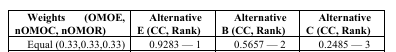

#### **03.3.2 Todos los pesos iguales + 7 Métodos**

In [8]:
methods = [
    "topsis",
    "vikor",
    "copras",
    "aras",
    "codas",
    "edas",
    "moora",
]

output = ranker.rank_all_methods_as_dict(
    methods=methods,
    weight_method="equal_weights",
)

output

/usr/local/lib/python3.12/dist-packages/pymcdm/methods/vikor.py:100: RuntimeWarning: invalid value encountered in divide
  + (1 - v) * (R - Rstar) / (Rminus - Rstar)


{'weighting': {'method': 'equal_weights',
  'weights': [0.3333333333333333, 0.3333333333333333, 0.3333333333333333],
  'dimensions': ['OMOC', 'OMOE', 'OMOR'],
  'weights_by_dimension': {'OMOC': 0.3333333333333333,
   'OMOE': 0.3333333333333333,
   'OMOR': 0.3333333333333333}},
 'matrix_orientation': 'all_benefit',
 'methods': {'topsis': {'method': 'topsis',
   'weight_method': 'equal_weights',
   'alternatives': ['B', 'C', 'E'],
   'dimensions': ['OMOC', 'OMOE', 'OMOR'],
   'weights': [0.3333333333333333, 0.3333333333333333, 0.3333333333333333],
   'weights_by_dimension': {'OMOC': 0.3333333333333333,
    'OMOE': 0.3333333333333333,
    'OMOR': 0.3333333333333333},
   'scores': [0.5327485830028733, 0.44587062072142297, 0.585786437626905],
   'scores_by_alternative': {'B': 0.5327485830028733,
    'C': 0.44587062072142297,
    'E': 0.585786437626905},
   'ranking_positions': [2, 3, 1],
   'ranking_by_alternative': {'B': 2, 'C': 3, 'E': 1},
   'ranked_alternatives': ['E', 'B', 'C'],
   'be

#### **03.3.3 Pesos por Entropy + 7 Métodos**

In [9]:
output = ranker.rank_all_methods_as_dict(
    weight_method="entropy",
)

output

{'weighting': {'method': 'entropy',
  'weights': [0.17565541795052647, 0.0026238917727137248, 0.8217206902767598],
  'dimensions': ['OMOC', 'OMOE', 'OMOR'],
  'weights_by_dimension': {'OMOC': 0.17565541795052647,
   'OMOE': 0.0026238917727137248,
   'OMOR': 0.8217206902767598}},
 'matrix_orientation': 'all_benefit',
 'methods': {'topsis': {'method': 'topsis',
   'weight_method': 'entropy',
   'alternatives': ['B', 'C', 'E'],
   'dimensions': ['OMOC', 'OMOE', 'OMOR'],
   'weights': [0.17565541795052647, 0.0026238917727137248, 0.8217206902767598],
   'weights_by_dimension': {'OMOC': 0.17565541795052647,
    'OMOE': 0.0026238917727137248,
    'OMOR': 0.8217206902767598},
   'scores': [0.627362156637146, 0.15176987809634984, 0.996887101029412],
   'scores_by_alternative': {'B': 0.627362156637146,
    'C': 0.15176987809634984,
    'E': 0.996887101029412},
   'ranking_positions': [2, 3, 1],
   'ranking_by_alternative': {'B': 2, 'C': 3, 'E': 1},
   'ranked_alternatives': ['E', 'B', 'C'],
   '

#### **03.3.4 Pesos por CRITIC + 7 Métodos**

In [10]:
output = ranker.rank_all_methods_as_dict(
    weight_method="critic",
)

output

{'weighting': {'method': 'critic',
  'weights': [0.3286414272812265, 0.06916677398769838, 0.602191798731075],
  'dimensions': ['OMOC', 'OMOE', 'OMOR'],
  'weights_by_dimension': {'OMOC': 0.3286414272812265,
   'OMOE': 0.06916677398769838,
   'OMOR': 0.602191798731075}},
 'matrix_orientation': 'all_benefit',
 'methods': {'topsis': {'method': 'topsis',
   'weight_method': 'critic',
   'alternatives': ['B', 'C', 'E'],
   'dimensions': ['OMOC', 'OMOE', 'OMOR'],
   'weights': [0.32864142728122653, 0.0691667739876984, 0.6021917987310751],
   'weights_by_dimension': {'OMOC': 0.32864142728122653,
    'OMOE': 0.0691667739876984,
    'OMOR': 0.6021917987310751},
   'scores': [0.514058042751469, 0.31358299584783333, 0.9084125133603909],
   'scores_by_alternative': {'B': 0.514058042751469,
    'C': 0.31358299584783333,
    'E': 0.9084125133603909},
   'ranking_positions': [2, 3, 1],
   'ranking_by_alternative': {'B': 2, 'C': 3, 'E': 1},
   'ranked_alternatives': ['E', 'B', 'C'],
   'best_alternati

#### **03.3.5 Pesos Por Usuario + 7 Métodos**

In [11]:
user_weights = [0.40, 0.35, 0.25]

In [12]:
output = ranker.rank_all_methods_as_dict(
    weight_method="user_defined_weights",
    user_weights=user_weights,
)

output

{'weighting': {'method': 'user_defined_weights',
  'weights': [0.4, 0.35, 0.25],
  'dimensions': ['OMOC', 'OMOE', 'OMOR'],
  'weights_by_dimension': {'OMOC': 0.4, 'OMOE': 0.35, 'OMOR': 0.25}},
 'matrix_orientation': 'all_benefit',
 'methods': {'topsis': {'method': 'topsis',
   'weight_method': 'user_defined_weights',
   'alternatives': ['B', 'C', 'E'],
   'dimensions': ['OMOC', 'OMOE', 'OMOR'],
   'weights': [0.4, 0.35, 0.25],
   'weights_by_dimension': {'OMOC': 0.4, 'OMOE': 0.35, 'OMOR': 0.25},
   'scores': [0.4868560720047384, 0.5275975022984106, 0.5740533018900944],
   'scores_by_alternative': {'B': 0.4868560720047384,
    'C': 0.5275975022984106,
    'E': 0.5740533018900944},
   'ranking_positions': [3, 2, 1],
   'ranking_by_alternative': {'B': 3, 'C': 2, 'E': 1},
   'ranked_alternatives': ['E', 'C', 'B'],
   'best_alternative': 'E',
   'best_index': 2,
   'matrix_orientation': 'all_benefit'},
  'vikor': {'method': 'vikor',
   'weight_method': 'user_defined_weights',
   'alternativ

#### **03.3.6 Todos los Métodos de Peso + 7 Métodos**

In [13]:
output = ranker.rank_all_weight_methods_as_dict(
    methods=[
        "topsis",
        "vikor",
        "copras",
        "aras",
        "codas",
        "edas",
        "moora",
        "mabac",
        "marcos",
        "waspas",
    ],
    user_weights=[0.40, 0.35, 0.25],
)

output

{'equal_weights': {'weighting': {'method': 'equal_weights',
   'weights': [0.3333333333333333, 0.3333333333333333, 0.3333333333333333],
   'dimensions': ['OMOC', 'OMOE', 'OMOR'],
   'weights_by_dimension': {'OMOC': 0.3333333333333333,
    'OMOE': 0.3333333333333333,
    'OMOR': 0.3333333333333333}},
  'matrix_orientation': 'all_benefit',
  'methods': {'topsis': {'method': 'topsis',
    'weight_method': 'equal_weights',
    'alternatives': ['B', 'C', 'E'],
    'dimensions': ['OMOC', 'OMOE', 'OMOR'],
    'weights': [0.3333333333333333, 0.3333333333333333, 0.3333333333333333],
    'weights_by_dimension': {'OMOC': 0.3333333333333333,
     'OMOE': 0.3333333333333333,
     'OMOR': 0.3333333333333333},
    'scores': [0.5327485830028733, 0.44587062072142297, 0.585786437626905],
    'scores_by_alternative': {'B': 0.5327485830028733,
     'C': 0.44587062072142297,
     'E': 0.585786437626905},
    'ranking_positions': [2, 3, 1],
    'ranking_by_alternative': {'B': 2, 'C': 3, 'E': 1},
    'ranked

In [14]:
import json

print(
    json.dumps(
        output,
        indent=4,
        ensure_ascii=False,
    )
)

{
    "equal_weights": {
        "weighting": {
            "method": "equal_weights",
            "weights": [
                0.3333333333333333,
                0.3333333333333333,
                0.3333333333333333
            ],
            "dimensions": [
                "OMOC",
                "OMOE",
                "OMOR"
            ],
            "weights_by_dimension": {
                "OMOC": 0.3333333333333333,
                "OMOE": 0.3333333333333333,
                "OMOR": 0.3333333333333333
            }
        },
        "matrix_orientation": "all_benefit",
        "methods": {
            "topsis": {
                "method": "topsis",
                "weight_method": "equal_weights",
                "alternatives": [
                    "B",
                    "C",
                    "E"
                ],
                "dimensions": [
                    "OMOC",
                    "OMOE",
                    "OMOR"
                ],
                "weig